# Slater determinant → MPS: `mps_cpmc_new.py` against ITensorGaussianMPS.jl

Both codes implement the Fishman–White construction ([PRB 92, 075132](https://doi.org/10.1103/PhysRevB.92.075132)): diagonalize the correlation matrix block by block, turn every block eigenvector into a ladder of nearest-neighbour Givens rotations, and apply the inverse circuit to an occupation product state. [ITensorGaussianMPS.jl](https://github.com/ITensor/ITensorGaussianMPS.jl) (v0.1.16, `slater_determinant_to_mps`) is the reference here. It runs in-process through `juliacall`, and every result from either code is also checked against the exact determinant amplitudes $\langle n|\Phi\rangle=\det\Phi[\text{occupied rows}]$ on the full $2^L$ (or $4^L$) space.

**Findings** (L = 12 test determinants: half-filled chain, chain at N = 5, random; plus ITensor's own L = 20 example):

1. **Without truncation, the two codes give the same state.** 1 − F ≤ 5e-16 against each other and against $\det$. `gauge × MPS` gives the signed amplitudes to ≤ 1.4e-14, and the bond dimensions match ITensor's bond for bond (§2). With the same tolerance, the `adaptive` plan has ITensor's block sizes and gate sites. On ITensor's README chain it reproduces the gate count, bond dimension and infidelity exactly (§3).
2. **The circuits differ in one respect only: ties.** At alternate steps the block holds both an exactly empty and an exactly occupied mode, and round-off decides which one each code isolates. With ITensor's choices imposed, your gate magnitudes |c|, |s| match ITensor's to ≤ 7e-11 (§2).
3. **Under truncation there are two differences, and both are identified.** (a) The ties. (b) NDTensors' `truncate!` never splits a pair of weights within 0.1 %. On the particle–hole-symmetric chain ITensor therefore keeps fewer than χ states, and its infidelity is 1.15–1.9× yours at χ = 2, 4, 8, 16, 32 (at χ = 3, 6, 12, 24 the two agree). With both imposed (ITensor's choices and ITensor's rule), `channel_mps` reproduces ITensor's truncated MPS to 1 − F ≤ 9e-16 at every χ (§4). Your gate application, centre moves and per-sector truncation are equivalent to ITensor's.
4. **ITensor fails at `maxdim = 1` on the half-filled chain.** The first gate yields Schmidt weights of exactly (½, ½). The pair rule drops both, leaving a zero-dimensional bond, and the next QR crashes (§4).
5. **Spinful: `combine_channels` matches ITensor's Electron MPS** and the interleaved-order determinant to 1e-16. The check is sensitive: dropping the interleaving sign would give fidelity 0.001 (§5).
6. **Frozen plans cost up to 2× at χ = 4.** For walkers away from the plan reference, freezing the plan (as CPMC does) raises the infidelity by up to 2× over re-planning each walker as ITensor does. Re-planning with your code matches ITensor (§6).

### One-time setup

The Julia side lives in `itensor_gmps_env/` (Project + Manifest: ITensors 0.9.32, ITensorMPS 0.4.2, ITensorGaussianMPS 0.1.16, PythonCall 0.9.36). On a new machine:

```bash
brew install juliaup && juliaup add release                        # Julia 1.13
cd trot/gmps/itensor_gmps_env
julia --project=. -e 'using Pkg; Pkg.Registry.add("General");
    Pkg.Registry.add(url="https://github.com/ITensor/ITensorRegistry"); Pkg.instantiate()'
~/.trot/bin/python -m pip install juliacall                          # 0.9.36, matches PythonCall
```

ITensorGaussianMPS is only in the ITensor registry, as its README says. `juliacall` has to be imported before JAX, and it has to be pointed at the real Julia binary, not at juliaup's launcher. The import cell below does both.

In [1]:
from pathlib import Path

# ---- small test determinants, each with a dense 2^L reference
L_SMALL = 12
EPS = 1.0e-10                    # purity tolerance: ITensor eigval_cutoff = your occupation_tolerance
CHIS = (1, 2, 3, 4, 6, 8, 12, 16, 24, 32)
SEED = 7
# ---- ITensorGaussianMPS README example
L_README, NF_README = 20, 10
# ---- spinful comparison: up = open chain, down = chain + staggered potential
L_SPIN, N_UP, N_DN, STAGGER = 8, 4, 3, 0.7
# ---- walkers away from the plan reference
WALKER_CHI = 4                   # mps_cpmc_new.Config.walker_channel_chi
DELTAS = (1e-4, 1e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0)
SAMPLES = 6
# ---- Julia project with ITensorGaussianMPS
JULIA_ENV = Path("itensor_gmps_env").resolve()

In [2]:
import itertools
import os
import subprocess
import sys

# juliacall first (before JAX), pointed at the real binary rather than juliaup's launcher
os.environ["PYTHON_JULIAPKG_EXE"] = subprocess.run(
    ["julia", "--startup-file=no", "-e", "print(joinpath(Sys.BINDIR, Base.julia_exename()))"],
    capture_output=True, text=True, check=True).stdout
os.environ["PYTHON_JULIAPKG_PROJECT"] = str(JULIA_ENV)
from juliacall import JuliaError, Main as jl

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))           # this folder: mps_cpmc_new.py
import mps_cpmc_new as mcn

jl.seval("""
using ITensors, ITensorMPS, ITensorGaussianMPS, LinearAlgebra

# Site tensors as dense (left bond, physical, right bond) arrays, with size-1 bonds at the ends.
function dense_tensors(ψ::MPS)
    s, L = siteinds(ψ), length(ψ)
    map(1:L) do j
        l = j > 1 ? linkind(ψ, j - 1) : nothing
        r = j < L ? linkind(ψ, j) : nothing
        A = Array(ψ[j], filter(!isnothing, [l, s[j], r])...)
        reshape(A, isnothing(l) ? 1 : dim(l), dim(s[j]), isnothing(r) ? 1 : dim(r))
    end
end

# Fishman-White circuit: mode occupations, and the Givens list as rows (i1, i2, c, s), 1-based sites.
function fw_circuit(Φ; eigval_cutoff=1e-8, maxblocksize=size(Φ, 1))
    ns, V = slater_determinant_to_gmps(Matrix{Float64}(Φ), size(Φ, 1); eigval_cutoff, maxblocksize)
    return ns, [Float64(getfield(g, f)) for g in V.rotations, f in (:i1, :i2, :c, :s)]
end

# Spinless determinant -> MPS on Fermion sites. eigval_cutoff and maxblocksize go to the circuit,
# maxdim and cutoff to ITensorMPS.apply.
function fw_mps(Φ; kwargs...)
    s = siteinds("Fermion", size(Φ, 1); conserve_qns=true)
    return dense_tensors(slater_determinant_to_mps(s, Matrix{Float64}(Φ); kwargs...))
end

# Spinful determinant -> MPS on Electron sites, local basis |0>, |up>, |dn>, |up dn>.
function fw_mps_electron(Φu, Φd; kwargs...)
    s = siteinds("Electron", size(Φu, 1); conserve_qns=true)
    return dense_tensors(slater_determinant_to_mps(s, Matrix{Float64}(Φu), Matrix{Float64}(Φd); kwargs...))
end
""")
print("Julia", jl.seval("string(VERSION)"), "| ITensorGaussianMPS", jl.seval("string(pkgversion(ITensorGaussianMPS))"),
      "| ITensorMPS", jl.seval("string(pkgversion(ITensorMPS))"), "| ITensors", jl.seval("string(pkgversion(ITensors))"))

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#8e5bd0", "#d4a20f", "#d6457a", "#3b9ab2", "#7a5230"]
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 14, "axes.labelsize": 10, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2.0,
    "lines.solid_capstyle": "round", "legend.frameon": False, "font.size": 10,
})
LEGEND = dict(loc="upper left", bbox_to_anchor=(1.01, 1.0))

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Julia 1.13.1 | ITensorGaussianMPS 0.1.16 | ITensorMPS 0.4.2 | ITensors 0.9.32


In [3]:
def to_np(tensors):
    """Julia arrays -> list of numpy (Dl, d, Dr) arrays."""
    return [np.array(t) for t in tensors]


def dense(tensors):
    """Dense state of an open MPS, first site most significant."""
    psi = np.ones((1, 1))
    for A in tensors:
        A = np.asarray(A)
        psi = np.einsum("xa,apb->xpb", psi, A).reshape(-1, A.shape[-1])
    return psi.reshape(-1)


def bonds(tensors):
    return [np.shape(A)[2] for A in tensors][:-1]


def infidelity(a, b):
    return 1.0 - (a @ b) ** 2 / ((a @ a) * (b @ b))


def amp_error(v, exact):
    """Largest amplitude error after normalising v and fixing its global sign against exact."""
    v = v * np.sign(v @ exact) * np.linalg.norm(exact) / np.linalg.norm(v)
    return np.abs(v - exact).max()


def exact_spinless(C):
    """<n|Phi> = det C[occupied rows], in the basis c+_{i1}...c+_{iN}|0> with i1 < ... < iN."""
    L, N = C.shape
    occ = np.array(list(itertools.combinations(range(L), N)))
    psi = np.zeros(2 ** L)
    psi[(1 << (L - 1 - occ)).sum(1)] = np.linalg.det(C[occ])
    return psi


def exact_electron(Cu, Cd, interleave_sign=True):
    """Local index n_up + 2 n_dn per site, fermion order (1up, 1dn, 2up, 2dn, ...). Without
    interleave_sign: the order (all up)(all down) instead."""
    L = Cu.shape[0]
    bits = (np.arange(2 ** L)[:, None] >> (L - 1 - np.arange(L))) & 1       # [config, site]
    downs_left = np.cumsum(bits, axis=1) - bits                               # downs strictly left of a site
    amp = exact_spinless(Cu)[:, None] * exact_spinless(Cd)[None, :]           # [up config, down config]
    if interleave_sign:                                                       # each up passes those downs
        amp = amp * (-1.0) ** (bits[:, None, :] * downs_left[None, :, :]).sum(-1)
    index = (bits[:, None, :] + 2 * bits[None, :, :]) @ (4 ** (L - 1 - np.arange(L)))
    psi = np.zeros(4 ** L)
    psi[index.ravel()] = amp.ravel()
    return psi


def chain_orbitals(L, N, potential=0.0):
    return np.linalg.eigh(mcn.hopping_matrix(L, 1.0) + np.diag(np.broadcast_to(potential, L)))[1][:, :N].copy()


def n_gates(plan):
    return int(plan.block_sizes.sum() - len(plan.block_sizes))


rng = np.random.default_rng(SEED)
CASES = {
    "chain L=12 N=6": chain_orbitals(L_SMALL, 6),
    "chain L=12 N=5": chain_orbitals(L_SMALL, 5),
    "random L=12 N=5": np.linalg.qr(rng.standard_normal((L_SMALL, 5)))[0],
}
EXACT = {name: exact_spinless(C) for name, C in CASES.items()}

## 1. The two implementations, step by step

| step | ITensorGaussianMPS (`src/gmps.jl`) | `mps_cpmc_new.py` |
|---|---|---|
| correlation matrix | $\Lambda=\Phi^*\Phi^T$ | $P=UU^T$ (real) |
| block for site $i$ | `isolate_subblock_eig`: grow $\Lambda[i{:}i{+}b]$ from $b=1$ until an eigenvalue is within `eigval_cutoff` of 0 or 1, at most `maxblocksize` | `make_orbital_plan`: `adaptive` grows the same way with no cap; `rank_exact` uses $B=\min(N,L-N)+1$ for every walker; `maximal` uses the rest of the chain |
| which mode | the lowest-entropy eigenvector, occupied or empty | `adaptive`: occupied iff $\lambda_{\min}>1-\lambda_{\max}$. This is the same criterion |
| Givens ladder | `givens_rotations`: `givens(v, n, n+1)` from the bottom up | `_rotate_mode_to_front`: `atan2(v[j], v[j-1])` from the bottom up |
| a new determinant | full re-plan | `channel_angles`: block sizes and occupations stay frozen from the reference; only the eigenvector is recomputed |
| gate | rows (1,0,0,0), (0,c,s,0), (0,−s,c,0), (0,0,0,1) in the basis |00⟩, |01⟩, |10⟩, |11⟩ | `gate_pair`: the same matrix |
| application | `apply(reverse(gates), product state; maxdim, cutoff)`: orthogonalize onto the gate, then a block-sparse SVD | `channel_mps`: `_move_centre` onto the gate, then `split_pair` with the kept count per sector frozen by `plan_bonds` |
| truncation | NDTensors `truncate!`: the `maxdim` largest $s^2$, but a pair within 0.1 % is never split. `cutoff` bounds the discarded weight | `plan_bonds`: exactly the `chi_max` largest $s$. `cutoff` is on $s/s_{\max}$ |
| spin | Electron sites: an interleaved $2L$ fermion circuit, merged pairwise | two $d=2$ channels, joined by `combine_channels` with sign $(-1)^{n_\alpha q_\beta}$ |
| overall sign | not tracked (normalised MPS) | `gauge` = det of the rotated occupied rows |

ITensor's `maxblocksize=b` allows blocks of $b+1$ sites, because it slices $\Lambda[i{:}i{+}b]$. So `maxblocksize` $=\min(N,L-N)$ is ITensor's counterpart of `rank_exact`.

## 2. Exact conversion (no bond truncation), spinless, L = 12

ITensor runs with `eigval_cutoff = EPS`, and your plans with `occupation_tolerance = EPS`. "amp err" is the largest amplitude error against $\det$. For your code the amplitude is `gauge × MPS`, taken as is. For ITensor it is normalised and sign-fixed, because ITensor does not track the overall sign.

In [4]:
print(f"{'determinant':17s} {'code':19s} {'gates':>5s} {'max D':>5s} {'1-F vs det':>11s} {'amp err':>9s} {'1-F vs ITensor':>15s}")
BONDS = {}
for name, C in CASES.items():
    ex = EXACT[name]
    it = to_np(jl.fw_mps(C, eigval_cutoff=EPS))
    v_it = dense(it)
    gates_it = len(np.array(jl.fw_circuit(C, eigval_cutoff=EPS)[1]))
    BONDS[name] = {"ITensor": bonds(it)}
    print(f"{name:17s} {'ITensor':19s} {gates_it:5d} {max(bonds(it)):5d} {infidelity(v_it, ex):11.1e} {amp_error(v_it, ex):9.1e} {'':>15s}")
    for mode in ("adaptive", "rank_exact", "maximal"):
        plan = mcn.make_orbital_plan(C, mode, EPS)
        tensors, charges, gauge = mcn.channel_mps(C, plan)
        v = float(gauge) * dense(tensors)
        BONDS[name][mode] = bonds(tensors)
        print(f"{'':17s} {'yours ' + mode:19s} {n_gates(plan):5d} {max(bonds(tensors)):5d} "
              f"{infidelity(v, ex):11.1e} {np.abs(v - ex).max():9.1e} {infidelity(v, v_it):15.1e}")
print()
for name, row in BONDS.items():
    print(name)
    for code_, b in row.items():
        print(f"   {code_:11s} {b}")

determinant       code                gates max D  1-F vs det   amp err  1-F vs ITensor
chain L=12 N=6    ITensor                36    64    -4.4e-16   2.7e-14                
                  yours adaptive         36    64    -4.4e-16   1.3e-14        -4.4e-16
                  yours rank_exact       36    64     2.2e-16   2.1e-16         0.0e+00
                  yours maximal          66    64     4.4e-16   4.0e-16         0.0e+00
chain L=12 N=5    ITensor                35    32    -4.4e-16   2.4e-14                
                  yours adaptive         35    32     0.0e+00   1.4e-14        -4.4e-16
                  yours rank_exact       35    32    -4.4e-16   3.6e-16        -4.4e-16
                  yours maximal          66    44    -4.4e-16   5.0e-16        -2.2e-16
random L=12 N=5   ITensor                35    32     0.0e+00   1.8e-15                
                  yours adaptive         35    32     0.0e+00   3.4e-16         4.4e-16
                  yours rank_exa

All four conversions are exact: 1 − F ≤ 5e-16 against the determinant and against each other. With `gauge`, your MPS gives the signed amplitudes to ≤ 1.4e-14, so the `gauge` factor is right too. Every bond equals ITensor's, except `maximal`'s middle bond for N = 5: 44 instead of the Schmidt rank 32. Untruncated splits keep the full rank each charge sector allows, because QR does not reveal rank. `maximal`'s long ladders let one sector exceed what the state needs, but the state is still exact. On these determinants `rank_exact` needs no more gates than `adaptive`.

### Circuits

Next, gate by gate. ITensor's block sizes can be read off its Givens list, because each ladder runs down to its start site. A **tie** is a step whose block holds both an exactly pure empty mode and an exactly pure occupied mode. Either choice is exact, and round-off decides which one each code takes. `forced_plan` is `make_orbital_plan` with ITensor's block sizes and occupied/empty choices imposed, so the gate angles can be compared one to one.

In [5]:
def ladders(G, L):
    """Block size per start site from ITensor's Givens list: each ladder runs down to its start site."""
    B, ladder = np.ones(L - 1, int), []
    for i1 in G[:, 0].astype(int) - 1:
        if ladder and i1 > ladder[-1]:
            B[ladder[-1]], ladder = len(ladder) + 1, []
        ladder.append(i1)
    if ladder:
        B[ladder[-1]] = len(ladder) + 1
    return B


def forced_plan(C, occupation, block_sizes):
    """make_orbital_plan with the block sizes and the occupied/empty choice of each step imposed."""
    U, references = np.array(C, float), []
    for k, B in enumerate(block_sizes):
        _, vectors = np.linalg.eigh((U @ U.T)[k:k + B, k:k + B])
        v = vectors[:, -1 if occupation[k] else 0]
        references.append(v.copy())
        mcn._rotate_mode_to_front(U, k, v)
    return mcn.OrbitalPlan(np.asarray(occupation), np.asarray(block_sizes), tuple(references), False)


def ties(C, plan, eps=EPS):
    """Steps whose block holds both a pure empty and a pure occupied mode, along the plan's own path."""
    U, out = np.array(C, float), []
    for k, B in enumerate(plan.block_sizes):
        w, vectors = np.linalg.eigh((U @ U.T)[k:k + B, k:k + B])
        out.append(bool(w[0] < eps and w[-1] > 1 - eps))
        mcn._rotate_mode_to_front(U, k, vectors[:, -1 if plan.occupation[k] else 0])
    return np.array(out)


FORCED = {}
for name, C in CASES.items():
    ns, G = map(np.array, jl.fw_circuit(C, eigval_cutoff=EPS))
    occ_it, blocks_it = np.rint(ns).astype(int), ladders(G, len(C))
    plan = mcn.make_orbital_plan(C, "adaptive", EPS)
    FORCED[name] = fplan = forced_plan(C, occ_it, blocks_it)
    angles, _ = mcn.channel_angles(C, fplan, xp=np)
    theta = np.array([float(t) for _, t in angles])
    same_sites = np.array_equal(np.array([p for p, _ in angles]) + 1, G[:, 0].astype(int))
    tie = ties(C, plan)
    print(f"{name}:  block sizes equal: {np.array_equal(plan.block_sizes, blocks_it)}   "
          f"gates {n_gates(plan)} vs {len(G)}")
    print(f"   occupations  yours   {plan.occupation}")
    print(f"                ITensor {occ_it}")
    print(f"   choices differ at steps {np.flatnonzero(plan.occupation[:-1] != occ_it[:-1]).tolist()};  "
          f"tie steps (yours) {np.flatnonzero(tie).tolist()}")
    print(f"   ITensor's choices forced: same gate sites {same_sites}, "
          f"max ||c|-|c_IT|| = {np.abs(np.abs(np.cos(theta)) - np.abs(G[:, 2])).max():.1e}, "
          f"max ||s|-|s_IT|| = {np.abs(np.abs(np.sin(theta)) - np.abs(G[:, 3])).max():.1e}, "
          f"gates with (c,s) of opposite sign {int(np.sum(np.cos(theta) * G[:, 2] < 0))}/{len(G)}")

chain L=12 N=6:  block sizes equal: True   gates 36 vs 36
   occupations  yours   [0 1 0 1 0 1 1 0 1 0 0 1]
                ITensor [1 0 1 0 1 0 1 0 1 0 0 1]
   choices differ at steps [0, 1, 2, 3, 4, 5];  tie steps (yours) [0, 2, 4, 6, 8, 10]
   ITensor's choices forced: same gate sites True, max ||c|-|c_IT|| = 4.3e-11, max ||s|-|s_IT|| = 6.7e-11, gates with (c,s) of opposite sign 22/36
chain L=12 N=5:  block sizes equal: True   gates 35 vs 35
   occupations  yours   [0 0 1 0 1 0 0 1 1 0 0 1]
                ITensor [0 0 1 0 1 0 1 0 1 0 0 1]
   choices differ at steps [6, 7];  tie steps (yours) [2, 4, 6, 8, 10]
   ITensor's choices forced: same gate sites True, max ||c|-|c_IT|| = 2.8e-11, max ||s|-|s_IT|| = 5.6e-11, gates with (c,s) of opposite sign 18/35
random L=12 N=5:  block sizes equal: True   gates 35 vs 35
   occupations  yours   [0 0 0 1 1 0 1 0 1 0 1 0]
                ITensor [0 0 1 0 1 0 1 0 1 0 1 0]
   choices differ at steps [2, 3];  tie steps (yours) [2, 4, 6, 8, 10]
   

Block sizes and gate sites are identical in all three cases. The occupation patterns first differ at a tie step: step 0 on the half-filled chain, 6 at N = 5, and 2 for the random determinant. At that step the block holds both a pure empty and a pure occupied mode, and ITensor's `sortperm(nB; by=entropy)` and your `values[0] > 1 - values[-1]` settle the tie by round-off. After that, the two codes follow different paths. On the half-filled chain they pick opposite modes for six steps in a row, yet the gate magnitudes still coincide, because particle–hole symmetry maps one choice onto the other.

With ITensor's choices imposed, |c| and |s| agree to ≤ 7e-11 on the chains and to 5e-14 on the random determinant. About half the gates carry (c, s) with the opposite overall sign. This comes from the eigenvector sign and from Julia's `givens`, which can return r < 0. The state does not depend on these signs (§2).

On these determinants, then, your plan's occupation pattern is decided by round-off. That doesn't matter without truncation, but it does once bonds are truncated (§4, §6).

## 3. ITensorGaussianMPS's own example: L = 20, N_f = 10 open chain

The README builds the free-fermion ground state with `maxblocksize = 4` (and the default `eigval_cutoff = 1e-8`). `examples/spinless_fermion.jl` and `examples/hubbard_1d_spin_conservation.jl` additionally use `eigval_cutoff = 1e-4`. Your code has no block cap; its `adaptive` tolerance plays the role of `eigval_cutoff`. $\Delta E=\langle H_0\rangle-E_0$ is computed from the dense $2^{20}$ state, with $E_0$ the sum of the 10 lowest orbital energies.

In [6]:
def chain_energy(psi, L, t=1.0):
    """<psi|H0|psi>/<psi|psi> for open-chain hopping; adjacent hops carry no Jordan-Wigner sign."""
    idx, energy = np.arange(2 ** L), 0.0
    for i in range(L - 1):
        bi, bj = L - 1 - i, L - 2 - i
        hop = idx[((idx >> bi) & 1) != ((idx >> bj) & 1)]
        energy += -t * psi[hop] @ psi[hop ^ ((1 << bi) | (1 << bj))]
    return energy / (psi @ psi)


energies, orbitals = np.linalg.eigh(mcn.hopping_matrix(L_README, 1.0))
C20, E0 = orbitals[:, :NF_README].copy(), energies[:NF_README].sum()
ex20 = exact_spinless(C20)
print(f"E0 = {E0:.12f}\n")
print(f"{'code and settings':44s} {'gates':>5s} {'max D':>5s} {'1-F vs det':>11s} {'dE':>10s}")
for label, kw in [("ITensor README: maxblocksize=4", dict(maxblocksize=4)),
                  ("ITensor examples: maxblocksize=4, cutoff 1e-4", dict(maxblocksize=4, eigval_cutoff=1e-4)),
                  ("ITensor eigval_cutoff=1e-8, no block cap", dict()),
                  ("ITensor eigval_cutoff=1e-4, no block cap", dict(eigval_cutoff=1e-4))]:
    tensors = to_np(jl.fw_mps(C20, **kw))
    v = dense(tensors)
    print(f"{label:44s} {len(np.array(jl.fw_circuit(C20, **kw)[1])):5d} {max(bonds(tensors)):5d} "
          f"{infidelity(v, ex20):11.2e} {chain_energy(v, L_README) - E0:10.2e}")
for eps in (1e-8, 1e-4):
    plan = mcn.make_orbital_plan(C20, "adaptive", eps)
    tensors, _, _ = mcn.channel_mps(C20, plan)
    v = dense(tensors)
    print(f"{f'yours adaptive, tolerance {eps:.0e}':44s} {n_gates(plan):5d} {max(bonds(tensors)):5d} "
          f"{infidelity(v, ex20):11.2e} {chain_energy(v, L_README) - E0:10.2e}")

E0 = -12.381489999655

code and settings                            gates max D  1-F vs det         dE
ITensor README: maxblocksize=4                  70    16    9.23e-05   2.13e-04
ITensor examples: maxblocksize=4, cutoff 1e-4    58    16    1.81e-04   4.16e-04
ITensor eigval_cutoff=1e-8, no block cap        80    64    4.01e-08   1.12e-07
ITensor eigval_cutoff=1e-4, no block cap        58    16    1.81e-04   4.16e-04
yours adaptive, tolerance 1e-08                 80    64    4.01e-08   1.12e-07
yours adaptive, tolerance 1e-04                 58    16    1.81e-04   4.16e-04


With the same tolerance and no block cap, your `adaptive` plan and ITensor agree exactly. At tolerance 1e-8: 80 gates, bond 64, 1 − F = 4.01e-8. At 1e-4: 58 gates, bond 16, 1 − F = 1.81e-4. The second setting is the `examples/*.jl` one, where `maxblocksize = 4` never binds. The README setting (tolerance 1e-8 capped at `maxblocksize = 4`) has no counterpart in your code. The cap cuts the gates from 80 to 70 and the bond from 64 to 16, at 1 − F = 9.2e-5. Your code has no block cap: only the tolerance changes the circuit.

## 4. Truncated conversion: a fixed maximum bond χ

ITensor: `slater_determinant_to_mps(...; maxdim=χ)`. Yours: `channel_mps(C, plan, plan_bonds(C, plan, chi_max=χ))`, planned on the determinant itself. Both apply the gates in the same order, move the orthogonality centre onto every gate, and truncate the two-site split. Two cases: the half-filled chain, whose Schmidt spectra are degenerate by particle–hole symmetry, and a random determinant with no symmetry.

ITensor failed, chain L=12 N=6, χ=1: BoundsError: attempt to access 0-element Vector{Pair{QN, Int64}} at index [1]


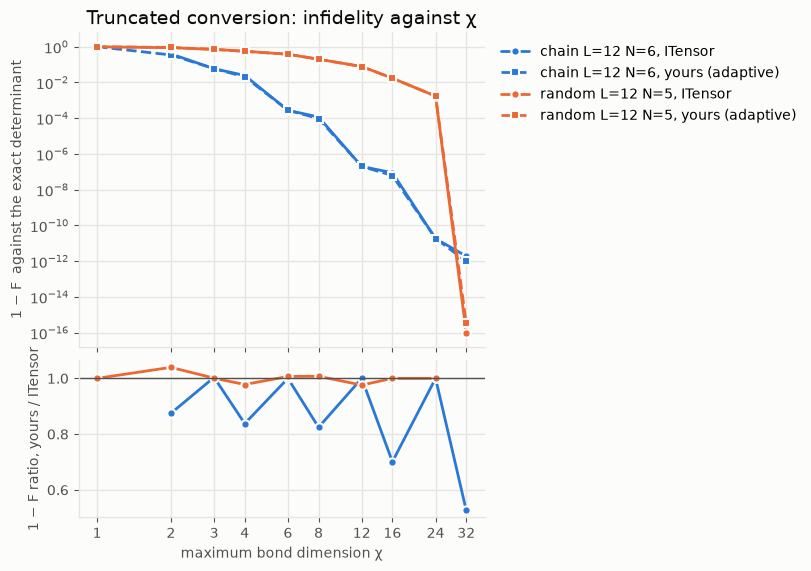

  χ   determinant      1-F ITensor  1-F yours yours/IT    1-F(IT, forced plan)  1-F(IT, forced plan + IT rule)   ITensor bonds
  1   chain L=12 N=6           nan  9.982e-01      nan                     nan                             nan   failed
  2   chain L=12 N=6     3.968e-01  3.471e-01     0.87                 3.4e-01                        -4.4e-16   [2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2]
  3   chain L=12 N=6     5.903e-02  5.925e-02     1.00                -6.7e-16                        -6.7e-16   [2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2]
  4   chain L=12 N=6     2.471e-02  2.070e-02     0.84                 1.1e-02                        -2.2e-16   [2, 4, 4, 4, 4, 4, 4, 4, 2, 4, 2]
  6   chain L=12 N=6     2.792e-04  2.792e-04     1.00                 2.2e-16                         2.2e-16   [2, 4, 6, 6, 6, 6, 6, 6, 6, 4, 2]
  8   chain L=12 N=6     1.169e-04  9.639e-05     0.82                 2.2e-05                         0.0e+00   [2, 4, 8, 8, 8, 8, 8, 6, 8, 4, 2]
 12   chain L=12 N

In [7]:
def plan_bonds_with(C, orbital_plan, chi, rule):
    """plan_bonds' dry run with the kept-count rule passed in; returns a BondPlan for channel_mps."""
    tensors = [np.eye(2)[int(o)].reshape(1, 2, 1) for o in orbital_plan.occupation]
    charges = [np.zeros(1, int)]
    for o in orbital_plan.occupation:
        charges.append(charges[-1] + int(o))
    angles, _ = mcn.channel_angles(np.asarray(C), orbital_plan, xp=np)
    kept_all, centre = [], None
    for site, theta in reversed(angles):
        centre = mcn._move_centre(tensors, charges, centre, site, xp=np)
        pair = mcn.gate_pair(tensors[site], tensors[site + 1], theta, xp=np)
        Dl, _, _, Dr = pair.shape
        matrix = pair.reshape(2 * Dl, 2 * Dr)
        svds = [np.linalg.svd(matrix[np.ix_(r, c)], full_matrices=False)
                for r, c, _ in mcn.sector_plan(charges[site], charges[site + 2]).sectors]
        kept = rule([s for _, s, _ in svds], chi)
        kept_all.append(kept)
        truncated = mcn.sector_plan(charges[site], charges[site + 2], kept)
        left = [u[:, :k] for (u, s, vh), k in zip(svds, kept) if k]
        right = [s[:k, None] * vh[:k] for (u, s, vh), k in zip(svds, kept) if k]
        left, right = mcn._assemble(left, right, truncated, xp=np)
        tensors[site], tensors[site + 1] = left.reshape(Dl, 2, -1), right.reshape(-1, 2, Dr)
        charges[site + 1] = truncated.middle_charges
        centre = site + 1
    return mcn.BondPlan(tuple(kept_all), tuple(charges), max(map(len, charges)), float("nan"))


def itensor_rule(singular_values, chi):
    """NDTensors.truncate! with maxdim only: keep the chi largest s^2, but if the last kept and the
    first dropped are within 0.1 %, raise the cut above both (a pair is never split)."""
    P = np.sort(np.concatenate(singular_values) ** 2)[::-1]
    n, cut = min(chi, len(P)), 0.0
    if n < len(P):
        cut = (P[n - 1] + P[n]) / 2
        if abs(P[n - 1] - P[n]) < 1e-3 * P[n - 1]:
            cut += 1e-3 * P[n - 1]
    return tuple(int(np.sum(s ** 2 > cut)) for s in singular_values)


TRUNC = {}
for name in ("chain L=12 N=6", "random L=12 N=5"):
    C, ex, fplan = CASES[name], EXACT[name], FORCED[name]
    plan = mcn.make_orbital_plan(C, "adaptive", EPS)
    for chi in CHIS:
        v_yours = dense(mcn.channel_mps(C, plan, mcn.plan_bonds(C, plan, chi_max=chi))[0])
        row = dict(itensor=np.nan, yours=infidelity(v_yours, ex), forced=np.nan, forced_rule=np.nan, itensor_bonds="failed")
        try:
            it = to_np(jl.fw_mps(C, eigval_cutoff=EPS, maxdim=chi))
        except JuliaError as err:
            print(f"ITensor failed, {name}, χ={chi}: {str(err).splitlines()[0]}")
        else:
            v_it = dense(it)
            v_forced = dense(mcn.channel_mps(C, fplan, mcn.plan_bonds(C, fplan, chi_max=chi))[0])
            v_rule = dense(mcn.channel_mps(C, fplan, plan_bonds_with(C, fplan, chi, itensor_rule))[0])
            row.update(itensor=infidelity(v_it, ex), forced=infidelity(v_forced, v_it),
                       forced_rule=infidelity(v_rule, v_it), itensor_bonds=bonds(it))
        TRUNC[name, chi] = row

FLOOR = 1e-16


def ratio(r):
    """yours / ITensor; nan where ITensor failed or both are exact."""
    return r["yours"] / r["itensor"] if r["itensor"] > 1e-13 else np.nan


fig, (ax, bx) = plt.subplots(2, 1, figsize=(8, 5.6), sharex=True, gridspec_kw={"height_ratios": (2, 1)},
                             constrained_layout=True)
for color, name in zip(PALETTE, ("chain L=12 N=6", "random L=12 N=5")):
    for key, ls, marker, who in (("itensor", "-", "o", "ITensor"), ("yours", "--", "s", "yours (adaptive)")):
        ax.plot(CHIS, [max(TRUNC[name, chi][key], FLOOR) for chi in CHIS], ls=ls, marker=marker, ms=6,
                color=color, mec=SURFACE, mew=1.5, label=f"{name}, {who}")
    bx.plot(CHIS, [ratio(TRUNC[name, chi]) for chi in CHIS], marker="o", ms=6, color=color, mec=SURFACE, mew=1.5)
ax.set_yscale("log"); ax.set_ylabel("1 − F  against the exact determinant")
ax.set_title("Truncated conversion: infidelity against χ")
ax.legend(**LEGEND)
bx.axhline(1.0, color=INK2, lw=1)
bx.set_xscale("log", base=2); bx.set_xticks(CHIS, [str(c) for c in CHIS])
bx.set_xlabel("maximum bond dimension χ"); bx.set_ylabel("1 − F ratio, yours / ITensor")
plt.show()

print(f"{'χ':>3s}   {'determinant':16s} {'1-F ITensor':>11s} {'1-F yours':>10s} {'yours/IT':>8s}   "
      f"{'1-F(IT, forced plan)':>21s} {'1-F(IT, forced plan + IT rule)':>31s}   ITensor bonds")
for name in ("chain L=12 N=6", "random L=12 N=5"):
    for chi in CHIS:
        r = TRUNC[name, chi]
        print(f"{chi:3d}   {name:16s} {r['itensor']:11.3e} {r['yours']:10.3e} {ratio(r):8.2f}   "
              f"{r['forced']:21.1e} {r['forced_rule']:31.1e}   {r['itensor_bonds']}")

**Random determinant.** The two codes agree to within 4 %. With ITensor's occupied/empty choices imposed (`FORCED`, from §2), `channel_mps` + `plan_bonds` reproduce ITensor's truncated MPS to 1 − F ≤ 7e-16 at every χ. So the remaining gap comes entirely from the tie steps.

**Half-filled chain.** At χ = 2, 4, 8, 16, 32 ITensor's infidelity is 1.15–1.9× yours, and its bonds stop short of χ: 1 for χ = 2, 6 for χ = 8, 12 for χ = 16, 28 for χ = 32. The cause is NDTensors `truncate!` (transcribed in `itensor_rule`). When the last kept and the first dropped weight are within 0.1 %, it moves the cut above both. Particle–hole symmetry pairs up the chain's Schmidt spectra exactly, so whenever χ falls inside a pair, ITensor drops the whole pair, while `plan_bonds` keeps exactly χ. Running your dry run with ITensor's rule on top of ITensor's choices (`plan_bonds_with(..., itensor_rule)`) reproduces ITensor to 1 − F ≤ 9e-16 at every χ. At χ = 3, 6, 12, 24 no pair straddles the cut, and the forced plan matches ITensor even without the rule.

**χ = 1 on the chain: ITensor fails.** The first gate applied, on sites (11, 12), is a 45° rotation (c = −s = 1/√2) on the product state, so the two-site Schmidt weights are exactly (½, ½). With `maxdim = 1` the pair rule raises the cut above both. The bond gets dimension 0, and the next QR fails on the empty QN index (`BoundsError` in `combiner`). Your code keeps one of the two states (1 − F = 0.998).

Which code does better depends on the goal. ITensor's rule keeps the symmetry of the spectrum, and your `plan_bonds` gives the lower infidelity at fixed χ.

## 5. Spinful determinant: Electron sites against `combine_channels`

Up spins: open-chain ground state with N_up = 4. Down spins: the same chain plus a staggered potential ±0.7, with N_dn = 3, so the two channels differ. L = 8, and the dense reference has $4^8$ amplitudes. ITensor builds an interleaved 16-site fermion circuit, whose up and down gates act on non-adjacent sites, and merges it into Electron sites. Your code converts each channel separately and interleaves them with the sign $(-1)^{n_\alpha q_\beta}$.

In [8]:
Cu = chain_orbitals(L_SPIN, N_UP)
Cd = chain_orbitals(L_SPIN, N_DN, STAGGER * (-1.0) ** np.arange(L_SPIN))
ex_spin = exact_electron(Cu, Cd)
ex_blocked = exact_electron(Cu, Cd, interleave_sign=False)

it = to_np(jl.fw_mps_electron(Cu, Cd, eigval_cutoff=EPS))
v_it = dense(it)
plan_u, plan_d = (mcn.make_orbital_plan(C, "adaptive", EPS) for C in (Cu, Cd))
alpha, q_alpha, gauge_a = mcn.channel_mps(Cu, plan_u)
beta, q_beta, gauge_b = mcn.channel_mps(Cd, plan_d)
combined, _ = mcn.combine_channels(alpha, q_alpha, beta, q_beta)
v_yours = float(gauge_a * gauge_b) * dense(combined)

print(f"ITensor vs det (interleaved order):  1-F = {infidelity(v_it, ex_spin):.1e}, amp err = {amp_error(v_it, ex_spin):.1e}")
print(f"yours   vs det (interleaved order):  1-F = {infidelity(v_yours, ex_spin):.1e}, "
      f"amp err = {np.abs(v_yours - ex_spin).max():.1e}  (gauge x MPS, no normalisation)")
print(f"yours   vs ITensor:                  1-F = {infidelity(v_yours, v_it):.1e}")
print(f"check that the sign convention is tested: 1-F(det with interleave sign, det without) = {infidelity(ex_spin, ex_blocked):.3f}")
print()
print("bonds  ITensor, default apply     ", bonds(it))
print("       ITensor, cutoff=1e-14      ", bonds(to_np(jl.fw_mps_electron(Cu, Cd, eigval_cutoff=EPS, cutoff=1e-14))))
print("       yours (D_alpha x D_beta)   ", bonds(combined))


def schmidt_rank(C, l, eps=EPS):
    """2^(number of fractional eigenvalues of the first l x l block of C C^T): Schmidt rank of det C at cut l."""
    w = np.linalg.eigvalsh((C @ C.T)[:l, :l])
    return 2 ** int(np.sum((w > eps) & (w < 1 - eps)))


print("       Schmidt rank of the state  ", [schmidt_rank(Cu, l) * schmidt_rank(Cd, l) for l in range(1, L_SPIN)])

ITensor vs det (interleaved order):  1-F = 4.4e-16, amp err = 2.6e-16
yours   vs det (interleaved order):  1-F = 0.0e+00, amp err = 2.4e-16  (gauge x MPS, no normalisation)
yours   vs ITensor:                  1-F = -4.4e-16
check that the sign convention is tested: 1-F(det with interleave sign, det without) = 0.999

bonds  ITensor, default apply      [4, 16, 64, 156, 64, 16, 4]
       ITensor, cutoff=1e-14       [4, 16, 64, 120, 64, 16, 4]
       yours (D_alpha x D_beta)    [4, 16, 64, 128, 64, 16, 4]
       Schmidt rank of the state   [4, 16, 64, 128, 64, 16, 4]


Both codes give the exact spinful state: 1 − F ≤ 4.4e-16 against the determinant in interleaved order (1↑, 1↓, 2↑, 2↓, …) and against each other. `gauge_a × gauge_b × MPS` gives the signed amplitudes to 2.4e-16. So the sign $(-1)^{n_\alpha q_\beta}$ in `combine_channels` follows the same convention as ITensor's Electron sites (ITensor applies the non-adjacent up/up and down/down gates with the correct fermionic signs), and the check is sensitive to that sign: without it the fidelity would be 0.001.

The bonds: your product bond $D_\alpha D_\beta$ equals the Schmidt rank at every cut (128 in the middle). ITensor's default `apply` leaves 156 in the middle, 28 of them redundant. With `cutoff = 1e-14`, which bounds the total discarded weight, it keeps 120. Truncation is not compared here, because the two codes truncate different things: ITensor truncates the joint d = 4 bond to `maxdim`, while your code truncates each channel to χ, which allows a joint bond of up to χ².

## 6. Walkers away from the plan reference

In CPMC your code plans once, on a reference determinant, and every walker reuses the frozen block sizes, occupations and per-sector kept counts: `make_walker_ops` → `channel_mps(qa, plan_a, bond_a)`. That fixes the shapes for JAX. ITensor has no frozen plan and re-plans each determinant from scratch. Here the reference is the half-filled chain (L = 12, N = 6, the `rhf` plan reference) and the walkers are $C_w=\mathrm{qr}(C_\text{ref}+\delta\,G)$ with $G$ i.i.d. normal. The top panel shows the mean over SAMPLES walkers per δ. The bottom panel shows each method's mean divided by ITensor's, on the same walkers. "Frozen" means that the plan and the kept counts both come from the reference. Everything uses χ = 4 per channel, the default `walker_channel_chi`.

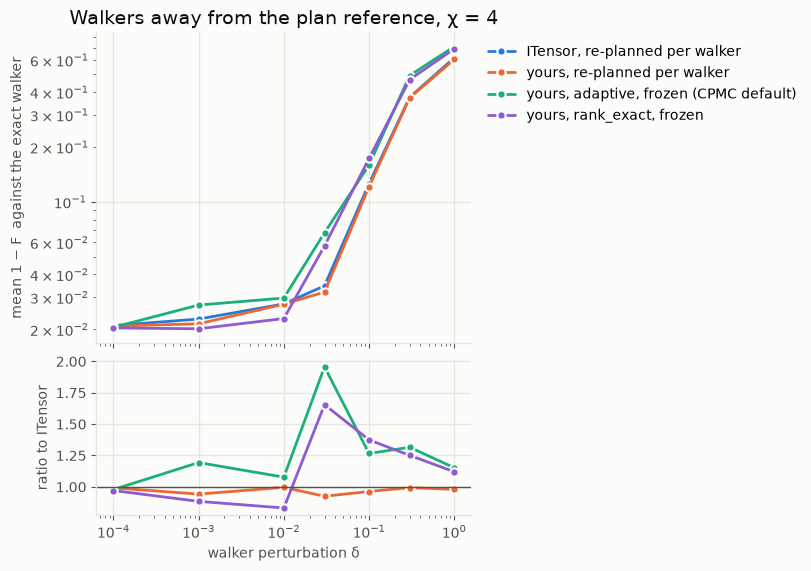

     δ 1-|<ref|w>|^2            itensor          replanned    frozen_adaptive  frozen_rank_exact   ratio to ITensor: replanned, frozen adaptive, frozen rank_exact
 1e-04      2.92e-07          2.098e-02          2.082e-02          2.052e-02          2.036e-02   0.99, 0.98, 0.97
 1e-03      3.32e-05          2.277e-02          2.145e-02          2.718e-02          2.014e-02   0.94, 1.19, 0.88
 1e-02      3.26e-03          2.757e-02          2.746e-02          2.970e-02          2.292e-02   1.00, 1.08, 0.83
 3e-02      3.65e-02          3.463e-02          3.204e-02          6.774e-02          5.730e-02   0.93, 1.96, 1.65
 1e-01      2.86e-01          1.259e-01          1.212e-01          1.594e-01          1.730e-01   0.96, 1.27, 1.37
 3e-01      9.61e-01          3.750e-01          3.726e-01          4.933e-01          4.691e-01   0.99, 1.32, 1.25
 1e+00      9.98e-01          6.172e-01          6.047e-01          7.113e-01          6.913e-01   0.98, 1.15, 1.12

frozen adaptive plan wit

In [9]:
C_ref = CASES["chain L=12 N=6"]
plan_a = mcn.make_orbital_plan(C_ref, "adaptive", EPS)
plan_r = mcn.make_orbital_plan(C_ref, "rank_exact", EPS)
bonds_a = mcn.plan_bonds(C_ref, plan_a, chi_max=WALKER_CHI)
bonds_r = mcn.plan_bonds(C_ref, plan_r, chi_max=WALKER_CHI)

METHODS = {
    "itensor": "ITensor, re-planned per walker",
    "replanned": "yours, re-planned per walker",
    "frozen_adaptive": "yours, adaptive, frozen (CPMC default)",
    "frozen_rank_exact": "yours, rank_exact, frozen",
}
walk = {key: np.zeros((len(DELTAS), SAMPLES)) for key in (*METHODS, "plan_only", "distance")}
rng = np.random.default_rng(SEED)
for i, delta in enumerate(DELTAS):
    for j in range(SAMPLES):
        Cw = np.linalg.qr(C_ref + delta * rng.standard_normal(C_ref.shape))[0]
        ex = exact_spinless(Cw)
        plan_w = mcn.make_orbital_plan(Cw, "adaptive", EPS)
        walk["distance"][i, j] = 1 - np.linalg.det(C_ref.T @ Cw) ** 2
        walk["itensor"][i, j] = infidelity(dense(to_np(jl.fw_mps(Cw, eigval_cutoff=EPS, maxdim=WALKER_CHI))), ex)
        walk["replanned"][i, j] = infidelity(dense(mcn.channel_mps(Cw, plan_w, mcn.plan_bonds(Cw, plan_w, chi_max=WALKER_CHI))[0]), ex)
        walk["frozen_adaptive"][i, j] = infidelity(dense(mcn.channel_mps(Cw, plan_a, bonds_a)[0]), ex)
        walk["frozen_rank_exact"][i, j] = infidelity(dense(mcn.channel_mps(Cw, plan_r, bonds_r)[0]), ex)
        walk["plan_only"][i, j] = infidelity(dense(mcn.channel_mps(Cw, plan_a)[0]), ex)

mean = {key: walk[key].mean(1) for key in METHODS}
fig, (ax, bx) = plt.subplots(2, 1, figsize=(8, 5.6), sharex=True, gridspec_kw={"height_ratios": (2, 1)},
                             constrained_layout=True)
for color, (key, label) in zip(PALETTE, METHODS.items()):
    ax.plot(DELTAS, mean[key], marker="o", ms=6, color=color, mec=SURFACE, mew=1.5, label=label)
    if key != "itensor":
        bx.plot(DELTAS, mean[key] / mean["itensor"], marker="o", ms=6, color=color, mec=SURFACE, mew=1.5)
ax.set_yscale("log"); ax.set_ylabel("mean 1 − F  against the exact walker")
ax.set_title(f"Walkers away from the plan reference, χ = {WALKER_CHI}")
ax.legend(**LEGEND)
bx.axhline(1.0, color=INK2, lw=1)
bx.set_xscale("log"); bx.set_xlabel("walker perturbation δ"); bx.set_ylabel("ratio to ITensor")
plt.show()

print(f"{'δ':>6s} {'1-|<ref|w>|^2':>13s} " + " ".join(f"{k:>18s}" for k in METHODS)
      + "   ratio to ITensor: replanned, frozen adaptive, frozen rank_exact")
for i, delta in enumerate(DELTAS):
    print(f"{delta:6.0e} {walk['distance'][i].mean():13.2e} " + " ".join(f"{mean[k][i]:18.3e}" for k in METHODS)
          + "   " + ", ".join(f"{mean[k][i] / mean['itensor'][i]:.2f}" for k in list(METHODS)[1:]))
print(f"\nfrozen adaptive plan without bond truncation: max 1-F over all walkers = {walk['plan_only'].max():.1e}")

- **Re-planning with your code matches ITensor.** The ratio is 0.93–1.00. The slight advantage comes from ITensor's pair rule, since the walkers stay close to a symmetric reference.
- **Freezing adaptive costs up to 2×.** At δ = 1e-4 (overlap with the reference 1 − 3e-7) the frozen adaptive plan is as good as ITensor (0.98). From δ = 1e-3 on it is 1.1–2.0× worse. With 6 walkers per δ the ratio is noisy, so read the trend rather than single points.
- **The loss comes from the frozen kept counts, not from the gates.** Without bond truncation, the frozen adaptive plan is exact for every walker (1 − F ≤ 7e-16). For this reference that holds by construction: at every step k the block size meets the rank bound $B>\min(N',\,L-k-N')$, where N′ is the number of particles still to place, and the plan's occupied/empty choice is the type that bound guarantees. So every walker's block holds the required pure mode. A reference whose adaptive blocks fall below the bound would add a circuit error on top; this is the `adaptive` caveat in the `mps_cpmc_new` docstring.
- **Frozen `rank_exact` is the most accurate near the reference.** For δ ≤ 1e-2 it is at 0.83–0.97× ITensor. Further out it is 1.1–1.7× worse.

## Conclusions

- **Correctness.** With ITensorGaussianMPS as the reference, `make_orbital_plan` + `channel_angles` + `channel_mps` (+ `combine_channels`) implement the same Fishman–White conversion. The states are exact and identical to ITensor's. Given the same mode choices and the same truncation rule, the truncated MPS match ITensor's to machine precision.
- **Differences that matter.**
  - Ties between exactly pure empty and occupied modes are settled by round-off in both codes. The resulting occupation pattern then fixes your frozen plan.
  - `plan_bonds` keeps exactly χ, while ITensor never splits a near-degenerate pair. At the same χ, yours is up to 1.9× more accurate on the symmetric chain, and ITensor cannot run χ = 1 there at all.
  - Your code has no `maxblocksize`, and ITensor has no frozen plan. Freezing costs up to 2× in walker infidelity at χ = 4, and all of that loss comes from the frozen kept counts.
- **Caveat.** Everything here is at L ≤ 12 (L = 20 for the README example), with the chain as the plan reference. Natural-orbital references from a DMRG trial were not tested.